In [ ]:
# connect Google Drive to Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# read the dataset from Google Drive
import pandas as pd

data = pd.read_csv('/content/drive/MyDrive/train1.csv')

# show first rows
data.head()

,headline,clickbait
0,Should I Get Bings,1
1,Which TV Female Friend Group Do You Belong In,1
2,"The New ""Star Wars: The Force Awakens"" Trailer...",1
3,"This Vine Of New York On ""Celebrity Big Brothe...",1
4,A Couple Did A Stunning Photo Shoot With Their...,1


In [ ]:
# check number of rows/columns and column names
print(data.shape)
print(data.columns)

(32000, 2)
Index(['headline', 'clickbait'], dtype='object')


In [ ]:
# check how many samples we have in each class
print(data['clickbait'].value_counts())

# check if there are missing values
print(data.isnull().sum())

clickbait
0    16001
1    15999
Name: count, dtype: int64
headline     0
clickbait    0
dtype: int64


In [ ]:
# remove missing rows
data = data.dropna()

# make all headlines lowercase
data['headline'] = data['headline'].str.lower()

# remove punctuation and special characters
data['headline'] = data['headline'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)

data.head()

,headline,clickbait
0,should i get bings,1
1,which tv female friend group do you belong in,1
2,the new star wars the force awakens trailer is...,1
3,this vine of new york on celebrity big brother...,1
4,a couple did a stunning photo shoot with their...,1


In [ ]:
# split the data into train, validation, and test sets
from sklearn.model_selection import train_test_split

x = data['headline']
y = data['clickbait']

# first split: 80% train and 20% temporary
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# second split: 10% validation and 10% test
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(len(x_train), len(x_val), len(x_test))

25600 3200 3200


In [ ]:
# baseline model: TF-IDF + Logistic Regression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# convert text into numerical features
tfidf = TfidfVectorizer(max_features=5000)

x_train_vec = tfidf.fit_transform(x_train)
x_val_vec = tfidf.transform(x_val)

# train logistic regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(x_train_vec, y_train)

# predict validation labels
pred = lr_model.predict(x_val_vec)

In [ ]:
# evaluate the baseline model
print("accuracy:", accuracy_score(y_val, pred))
print("precision:", precision_score(y_val, pred))
print("recall:", recall_score(y_val, pred))
print("f1:", f1_score(y_val, pred))

print(classification_report(y_val, pred))

# store for comparison later
lr_acc = accuracy_score(y_val, pred)
lr_f1  = f1_score(y_val, pred)

accuracy: 0.961875
precision: 0.9677215189873418
recall: 0.955625
f1: 0.9616352201257862
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1600
           1       0.97      0.96      0.96      1600

    accuracy                           0.96      3200
   macro avg       0.96      0.96      0.96      3200
weighted avg       0.96      0.96      0.96      3200



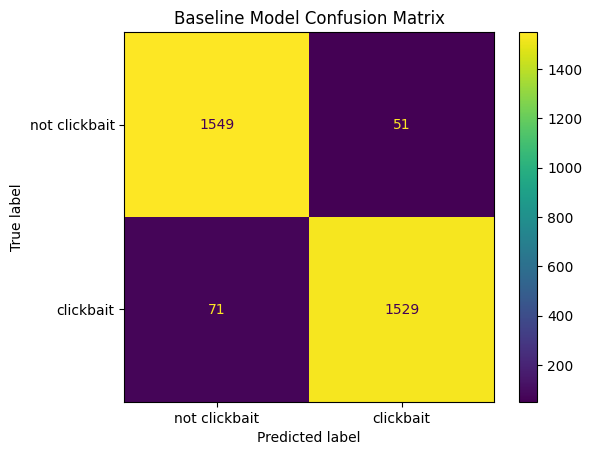

In [ ]:
# confusion matrix for the baseline model
cm = confusion_matrix(y_val, pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["not clickbait", "clickbait"]
)

disp.plot()
plt.title("Baseline Model Confusion Matrix")
plt.show()

In [ ]:
# libraries for LSTM model
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# convert headlines into sequences of numbers

max_words = 10000
max_len = 30

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(x_train)

x_train_seq = tokenizer.texts_to_sequences(x_train)
x_val_seq = tokenizer.texts_to_sequences(x_val)
x_test_seq = tokenizer.texts_to_sequences(x_test)

x_train_pad = pad_sequences(x_train_seq, maxlen=max_len, padding='post')
x_val_pad = pad_sequences(x_val_seq, maxlen=max_len, padding='post')
x_test_pad = pad_sequences(x_test_seq, maxlen=max_len, padding='post')

print(x_train_pad.shape)
print(x_val_pad.shape)
print(x_test_pad.shape)

(25600, 30)
(3200, 30)
(3200, 30)


In [ ]:
# build LSTM model

lstm_model = Sequential()

lstm_model.add(Embedding(input_dim=max_words, output_dim=64))
lstm_model.add(LSTM(64))
lstm_model.add(Dropout(0.3))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# train LSTM model

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = lstm_model.fit(
    x_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_val_pad, y_val),
    callbacks=[early_stop]
)

Epoch 1/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.9430 - loss: 0.1375 - val_accuracy: 0.9725 - val_loss: 0.0788
Epoch 2/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.9886 - loss: 0.0360 - val_accuracy: 0.9716 - val_loss: 0.0878
Epoch 3/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.9943 - loss: 0.0204 - val_accuracy: 0.9638 - val_loss: 0.1425


In [ ]:
# evaluate LSTM model on validation set

lstm_pred_prob = lstm_model.predict(x_val_pad)
lstm_pred = (lstm_pred_prob > 0.5).astype(int)

print("accuracy:", accuracy_score(y_val, lstm_pred))
print("precision:", precision_score(y_val, lstm_pred))
print("recall:", recall_score(y_val, lstm_pred))
print("f1:", f1_score(y_val, lstm_pred))

print(classification_report(y_val, lstm_pred))

# store for comparison later
lstm_acc = accuracy_score(y_val, lstm_pred)
lstm_f1  = f1_score(y_val, lstm_pred)

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
accuracy: 0.9725
precision: 0.9730913642052565
recall: 0.971875
f1: 0.9724828017510945
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1600
           1       0.97      0.97      0.97      1600

    accuracy                           0.97      3200
   macro avg       0.97      0.97      0.97      3200
weighted avg       0.97      0.97      0.97      3200



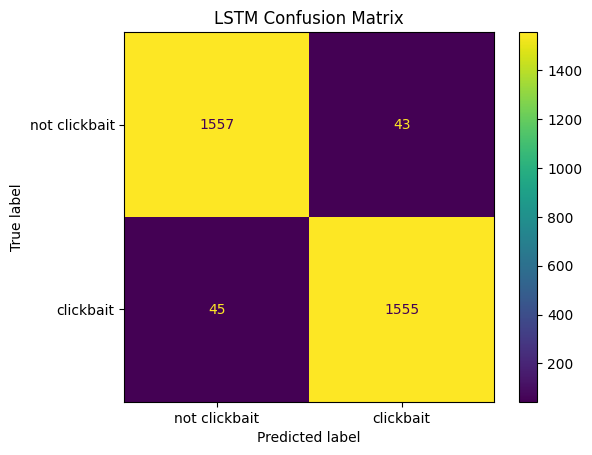

In [ ]:
# confusion matrix for LSTM model

cm_lstm = confusion_matrix(y_val, lstm_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lstm,
    display_labels=["not clickbait", "clickbait"]
)

disp.plot()
plt.title("LSTM Confusion Matrix")
plt.show()

In [ ]:
# compare baseline model and LSTM model

results = pd.DataFrame({
    'Model':    ['Logistic Regression', 'LSTM'],
    'Accuracy': [lr_acc, lstm_acc],
    'F1-score': [lr_f1,  lstm_f1]
})

print(results)

                 Model  Accuracy  F1-score
0  Logistic Regression  0.961875  0.961635
1                 LSTM  0.972500  0.972483


In [ ]:
# evaluate LSTM model on test set

test_pred_prob = lstm_model.predict(x_test_pad)
test_pred = (test_pred_prob > 0.5).astype(int)

print("Test Accuracy:", accuracy_score(y_test, test_pred))
print("Test Precision:", precision_score(y_test, test_pred))
print("Test Recall:", recall_score(y_test, test_pred))
print("Test F1-score:", f1_score(y_test, test_pred))

print(classification_report(y_test, test_pred))

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Test Accuracy: 0.9796875
Test Precision: 0.9830081812460667
Test Recall: 0.97625
Test F1-score: 0.9796174349325808
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1600
           1       0.98      0.98      0.98      1600

    accuracy                           0.98      3200
   macro avg       0.98      0.98      0.98      3200
weighted avg       0.98      0.98      0.98      3200



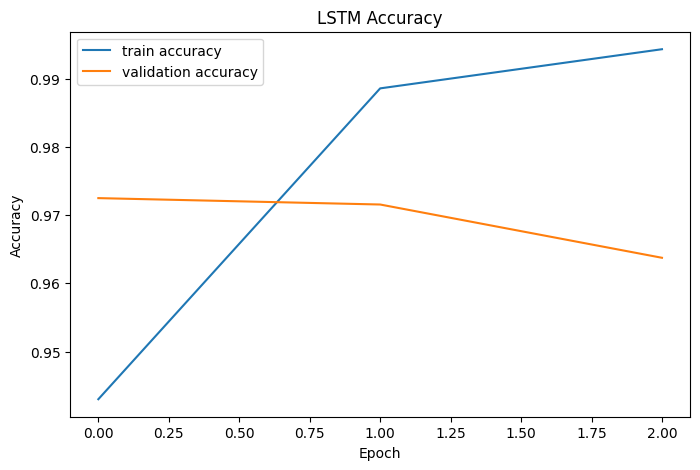

In [ ]:
# plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

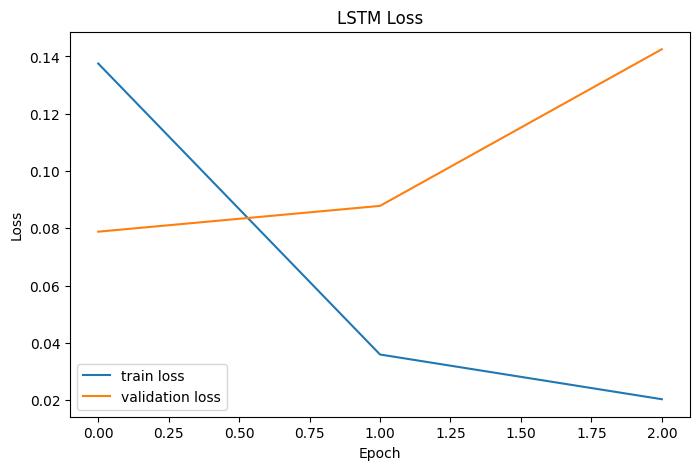

In [ ]:
# loss graph

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')

plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.show()